# Value-at-Risk (VaR) Forecasting with Machine Learning

this notebook builds a tool that tries to answer one question - "On a bad day, how much money could this stock portfolio realistically lose?"

this project trains machine learning models to directly estimate the boundary of the worst 5% of days, using current market conditions (volatility, interest rates, oil prices, etc.) as inputs.

The steps in the project:
1. Build a hypothetical $1,000,000 stock portfolio and pull historical prices.
2. Explore how the portfolio has behaved historically (its "returns").
3. Engineer features that describe the market environment on any given day.
4. Train three models - a simple historical baseline, a linear model, and XGBoost - to predict tomorrow's worst-case return.
5. Test which model is actually reliable using formal statistical backtests.
6. Package the winning model into a small web service (API).

In [30]:
!pip -q install -U yfinance xgboost scipy scikit-learn seaborn statsmodels joblib fastapi uvicorn

In [31]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from scipy.stats import skew, kurtosis

from sklearn.linear_model import QuantileRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_pinball_loss, mean_absolute_error
from sklearn.metrics import r2_score

from xgboost import XGBRegressor

import joblib

RANDOM_STATE = 42

ALPHA = 0.05

CONFIDENCE = 1 - ALPHA

PORTFOLIO_VALUE = 1_000_000

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Theoretical background

**What is "Value-at-Risk" (VaR)?** It's a single dollar number that is like saying "I am 95% confident I won't lose more than X dollars tomorrow." The other 5% of the time, losses could be worse than $X - VaR doesn't say by how much, just where the "bad day" line sits.

To compute that, we need:

- **Alpha (5%)** (signlificance level) - the slice of "worst days" we care about. We're looking at the bottom 5% of outcomes.
- **Confidence level (95%)** - the flip side of alpha
- **Portfolio value ($1,000,000)** - a hypothetical amount invested, purely so the risk estimate can be expressed in dollars instead of abstract percentages.


In [32]:
tickers = ["AAPL", "MSFT", "NVDA", "JPM", "XOM"]

weights = pd.Series({
    "AAPL": 0.25,
    "MSFT": 0.25,
    "NVDA": 0.20,
    "JPM": 0.15,
    "XOM": 0.15
})

print("Portfolio weights:")
display(weights.to_frame("Weight"))

print("\nTotal weight:", weights.sum())

Portfolio weights:


,Weight
AAPL,0.25
MSFT,0.25
NVDA,0.20
JPM,0.15
XOM,0.15



Total weight: 1.0


Here, the portfolio is 5 well-known US stocks, each held in a fixed weight of the total money invested:

- AAPL (Apple) and MSFT (Microsoft) - large technology companies, 25% each
- NVDA (Nvidia) - a more volatile tech/semiconductor stock, 20%
- JPM (JPMorgan) - a large bank, 15%
- XOM (Exxon Mobil) - an energy/oil company, 15%

The weights add up to 100% (all the money is invested, none held as cash). The goal below is to estimate the risk of this specific mix of stocks.


## Adding systematic risk factors

A stock portfolio doesn't move in isolation — it reacts to what's happening in the broader economy and markets. Below we pull five extra data series that act as a "weather report" for the market each day:

- S&P 500 (^GSPC) - a broad index of large US companies; a proxy for "how is the overall stock market doing today."
- VIX (^VIX) - often called the market's "fear gauge." It rises sharply when investors expect turbulence, and tends to spike right before or during bad days.
- 10-Year Treasury Yield (^TNX) - reflects the cost of borrowing money / investor expectations about interest rates and inflation.
- US Dollar Index (DX-Y.NYB) - how strong the US dollar is against other major currencies; currency swings can ripple into company earnings and commodity prices.
- WTI Crude Oil (CL=F) - an oil price benchmark; especially relevant here since the portfolio holds an energy company (XOM).

These aren't part of the portfolio itself — they're context the models can use to judge how risky today's environment is before predicting tomorrow's return.


In [33]:
factor_tickers = [
    "^GSPC",       # S&P 500
    "^VIX",        # VIX volatility index
    "^TNX",        # 10-year Treasury yield
    "DX-Y.NYB",    # US Dollar Index
    "CL=F"         # WTI crude oil futures
]

all_tickers = tickers + factor_tickers

factor_names = {
    "^GSPC": "S&P 500",
    "^VIX": "VIX",
    "^TNX": "10Y Treasury Yield",
    "DX-Y.NYB": "US Dollar Index",
    "CL=F": "WTI Oil"
}

print("Systematic risk factors:")
for ticker, name in factor_names.items():
    print(f"{ticker}: {name}")

Systematic risk factors:
^GSPC: S&P 500
^VIX: VIX
^TNX: 10Y Treasury Yield
DX-Y.NYB: US Dollar Index
CL=F: WTI Oil


Daily prices for all tickers above (portfolio stocks + market factors) are pulled from Yahoo Finance, starting in 2015

In [34]:
start_date = "2015-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

raw = yf.download(
    all_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
    group_by="column"
)

print("Downloaded data shape:", raw.shape)

display(raw.head())

Downloaded data shape: (2946, 50)


Price           Close                                                        \
Ticker           AAPL       CL=F   DX-Y.NYB        JPM       MSFT      NVDA   
Date                                                                          
2015-01-02  24.171755  52.689999  91.080002  46.066788  39.607182  0.481884   
2015-01-05  23.490797  50.040001  91.379997  44.636639  39.242950  0.473745   
2015-01-06  23.493017  47.930000  91.500000  43.479263  38.666965  0.459381   
2015-01-07  23.822433  48.650002  91.889999  43.545609  39.158253  0.458185   
2015-01-08  24.737745  48.790001  92.370003  44.518688  40.310215  0.475420   

Price                                                 ...       Volume  \
Ticker            XOM        ^GSPC   ^TNX       ^VIX  ...         AAPL   
Date                                                  ...                
2015-01-02  56.777897  2058.199951  2.123  17.790001  ...  212818400.0   
2015-01-05  55.224369  2020.579956  2.039  19.920000  ...  257142000.0   
2015-01-06  54.930759  2002.609985  1.963  21.120001  ...  263188400.0   
2015-01-07  55.487354  2025.900024  1.954  19.309999  ...  160423600.0   
2015-01-08  56.410931  2062.139893  2.016  17.010000  ...  237458000.0   

Price                                                               \
Ticker          CL=F DX-Y.NYB         JPM        MSFT         NVDA   
Date                                                                 
2015-01-02  268708.0      0.0  12600000.0  27913900.0  113680000.0   
2015-01-05  375782.0      0.0  20100600.0  39673900.0  197952000.0   
2015-01-06  451642.0      0.0  29074100.0  36447900.0  197764000.0   
2015-01-07  460083.0      0.0  23843200.0  29114100.0  321808000.0   
2015-01-08  362081.0      0.0  16971100.0  29645200.0  283780000.0   

Price                                           
Ticker             XOM         ^GSPC ^TNX ^VIX  
Date                                            
2015-01-02  10220400.0  2.708700e+09  0.0  0.0  
2015-01-05  18502400.0  3.799120e+09  0.0  0.0  
2015-01-06  16670700.0  4.460110e+09  0.0  0.0  
2015-01-07  13590700.0  3.805480e+09  0.0  0.0  
2015-01-08  15487500.0  3.934010e+09  0.0  0.0  

[5 rows x 50 columns]

yfinance normally returns MultiIndex columns when multiple tickers are downloaded

In [35]:
if isinstance(raw.columns, pd.MultiIndex):

    close = raw["Close"].copy()
    volume = raw["Volume"].copy()

else:
    raise ValueError(
        "Unexpected yfinance format. "
        "Please inspect raw.columns."
    )
print("Closing prices:")
display(close.head())

Closing prices:


Ticker,AAPL,CL=F,DX-Y.NYB,JPM,MSFT,NVDA,XOM,^GSPC,^TNX,^VIX
Date,,,,,,,,,,
2015-01-02,24.171755,52.689999,91.080002,46.066788,39.607182,0.481884,56.777897,2058.199951,2.123,17.790001
2015-01-05,23.490797,50.040001,91.379997,44.636639,39.242950,0.473745,55.224369,2020.579956,2.039,19.920000
2015-01-06,23.493017,47.930000,91.500000,43.479263,38.666965,0.459381,54.930759,2002.609985,1.963,21.120001
2015-01-07,23.822433,48.650002,91.889999,43.545609,39.158253,0.458185,55.487354,2025.900024,1.954,19.309999
2015-01-08,24.737745,48.790001,92.370003,44.518688,40.310215,0.475420,56.410931,2062.139893,2.016,17.010000


Let's see if there is any missing values

In [36]:
missing = close.isna().sum().sort_values(ascending=False)

print("Missing values by asset:")
display(missing.to_frame("Missing values"))

print("\nPercentage of missing values:")
display(
    (missing / len(close) * 100)
    .round(2)
    .to_frame("Missing %")
)

Missing values by asset:


,Missing values
Ticker,
^TNX,7
AAPL,6
CL=F,6
JPM,6
NVDA,6
MSFT,6
^GSPC,6
XOM,6
DX-Y.NYB,5



Percentage of missing values:


,Missing %
Ticker,
^TNX,0.24
AAPL,0.20
CL=F,0.20
JPM,0.20
NVDA,0.20
MSFT,0.20
^GSPC,0.20
XOM,0.20
DX-Y.NYB,0.17


It is a time series, so pasting mean value would not work. Therefore, let's a forward-fill.

In [37]:
close = close.ffill()

volume = volume.ffill()

print("Closing prices:")
display(close.head())

print("\nNumber of observations:", len(close))

Closing prices:


Ticker,AAPL,CL=F,DX-Y.NYB,JPM,MSFT,NVDA,XOM,^GSPC,^TNX,^VIX
Date,,,,,,,,,,
2015-01-02,24.171755,52.689999,91.080002,46.066788,39.607182,0.481884,56.777897,2058.199951,2.123,17.790001
2015-01-05,23.490797,50.040001,91.379997,44.636639,39.242950,0.473745,55.224369,2020.579956,2.039,19.920000
2015-01-06,23.493017,47.930000,91.500000,43.479263,38.666965,0.459381,54.930759,2002.609985,1.963,21.120001
2015-01-07,23.822433,48.650002,91.889999,43.545609,39.158253,0.458185,55.487354,2025.900024,1.954,19.309999
2015-01-08,24.737745,48.790001,92.370003,44.518688,40.310215,0.475420,56.410931,2062.139893,2.016,17.010000



Number of observations: 2946


In [38]:
missing = close.isna().sum().sort_values(ascending=False)

print("Missing values by asset:")
display(missing.to_frame("Missing values"))

print("\nPercentage of missing values:")
display(
    (missing / len(close) * 100)
    .round(2)
    .to_frame("Missing %")
)

Missing values by asset:


,Missing values
Ticker,
AAPL,0
CL=F,0
DX-Y.NYB,0
JPM,0
MSFT,0
NVDA,0
XOM,0
^GSPC,0
^TNX,0



Percentage of missing values:


,Missing %
Ticker,
AAPL,0.0
CL=F,0.0
DX-Y.NYB,0.0
JPM,0.0
MSFT,0.0
NVDA,0.0
XOM,0.0
^GSPC,0.0
^TNX,0.0


Everything is clean now.

## From prices to returns

Raw stock prices aren't directly comparable across companies. Instead, we convert prices into daily returns which is the percentage change from one day to the next, e.g. "AAPL was up 1.2% today."


In [39]:
asset_returns = close[tickers].pct_change()

print("Asset returns:")
display(asset_returns.head())

Asset returns:


Ticker,AAPL,MSFT,NVDA,JPM,XOM
Date,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN
2015-01-05,-0.028172,-0.009196,-0.016890,-0.031045,-0.027361
2015-01-06,0.000095,-0.014677,-0.030319,-0.025929,-0.005317
2015-01-07,0.014022,0.012706,-0.002605,0.001526,0.010133
2015-01-08,0.038422,0.029418,0.037617,0.022346,0.016645


In [40]:
portfolio_return = (
    asset_returns
    .mul(weights, axis=1)
    .sum(axis=1)
)

portfolio_return.name = "portfolio_return"

print("Portfolio return statistics:")
display(portfolio_return.describe())

Portfolio return statistics:


,portfolio_return
count,2946.000000
mean,0.001225
std,0.014988
min,-0.142645
25%,-0.005478
50%,0.001468
75%,0.008569
max,0.120672


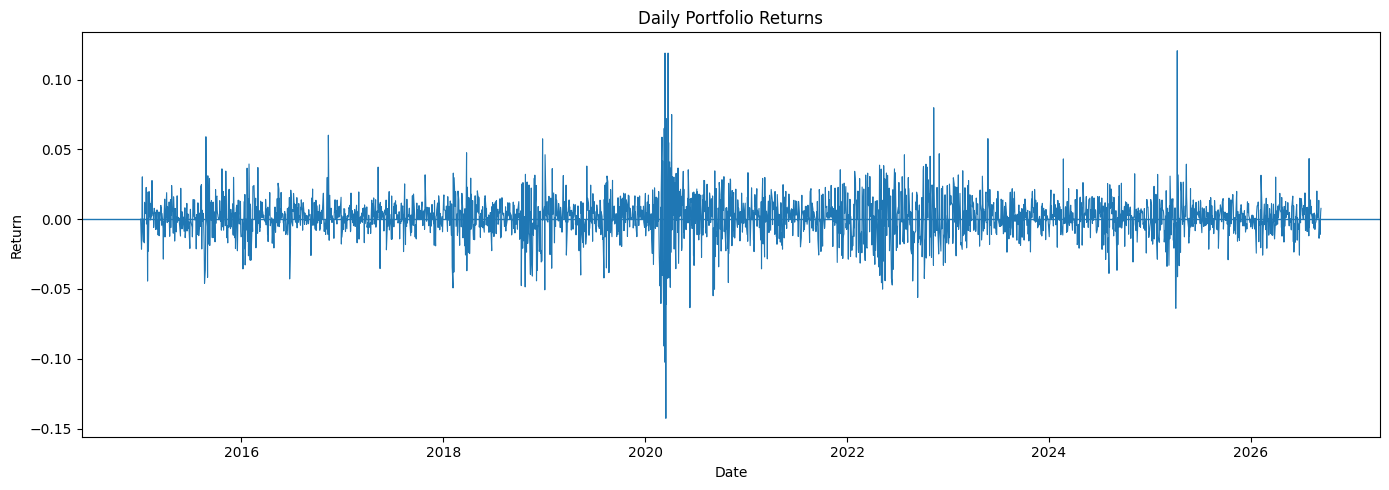

In [41]:
plt.figure(figsize=(14, 5))

plt.plot(
    portfolio_return.index,
    portfolio_return,
    linewidth=0.8
)

plt.axhline(0, linewidth=1)

plt.title("Daily Portfolio Returns")
plt.xlabel("Date")
plt.ylabel("Return")

plt.tight_layout()
plt.show()

As shown in the graph, there are significant spikes in return around the 2020, which is most likely related to COVID-19.

## What does "5% quantile" actually mean?

Imagine lining up every single day's portfolio return from worst to best, over several years. The **5% quantile** is the value at which 5% of all days were worse, and 95% of all days were better or equal.


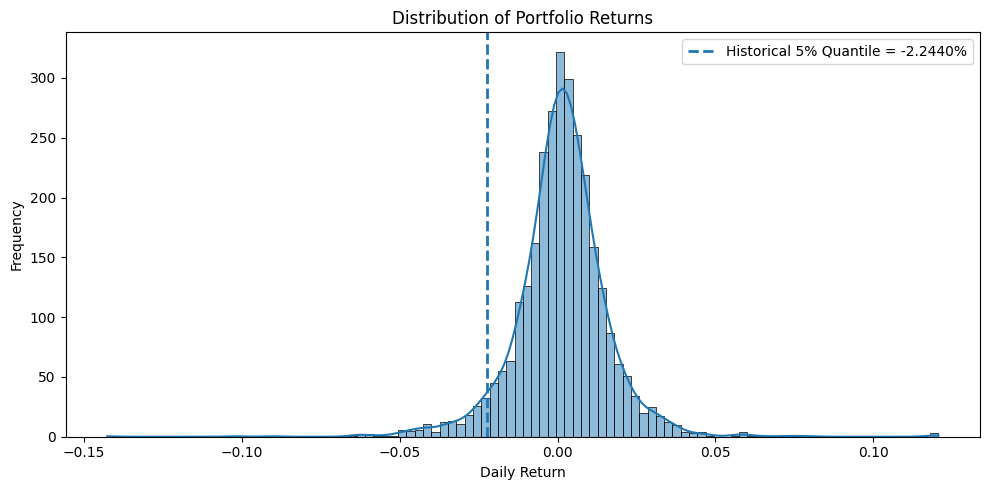

In [42]:
q05 = portfolio_return.quantile(ALPHA)

plt.figure(figsize=(10, 5))

sns.histplot(
    portfolio_return.dropna(),
    bins=100,
    kde=True
)

plt.axvline(
    q05,
    linestyle="--",
    linewidth=2,
    label=f"Historical 5% Quantile = {q05:.4%}"
)

plt.title("Distribution of Portfolio Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()
plt.show()

In [43]:
statistics = pd.Series({
    "Mean": portfolio_return.mean(),
    "Standard deviation": portfolio_return.std(),
    "Minimum": portfolio_return.min(),
    "Maximum": portfolio_return.max(),
    "Skewness": skew(portfolio_return.dropna()),
    "Excess kurtosis": kurtosis(portfolio_return.dropna(), fisher=True),
    "5% quantile": portfolio_return.quantile(0.05),
    "1% quantile": portfolio_return.quantile(0.01)
})

display(statistics.to_frame("Value"))

,Value
Mean,0.001225
Standard deviation,0.014988
Minimum,-0.142645
Maximum,0.120672
Skewness,-0.122115
Excess kurtosis,9.716560
5% quantile,-0.022440
1% quantile,-0.042403


- **Skewness** tells you whether extreme days lean more toward big losses or big gains. A negative number (common for stock portfolios) means the worst days tend to be *more extreme* than the best days - losses can be sharper than gains.
- **Excess kurtosis** tells you whether extreme days happen more often than a standard bell curve would predict. A positive number means "fat tails" - big up or down days are more frequent than the normal-distribution assumption suggests. This is exactly why a model that assumes a bell curve can be dangerously wrong for risk estimation, and part of the motivation for this project.


## Building the features

- **market_return / vix_change / rate_change / usd_return / oil_return** — today's moves in the five market factors introduced above.
- **ret_lag1 / ret_lag2 / ret_lag5** - the portfolio's own recent returns (yesterday, two days ago, last 5 days combined). "What just happened to us."
- **vol_5d / vol_20d / vol_60d** - how much the portfolio has been swinging around recently, over 1 week / 1 month / 3 months. Higher = more turbulent recently.
- **drawdown_60d** - how far the overall market currently sits below its own peak from the last 60 trading days. A proxy for "are we currently in a market slump."
- **portfolio_volume_change** - a liquidity/activity signal: is trading volume in these stocks picking up or drying up compared to normal.

All of these use only information available before the day we're trying to predict, the model is never shown the future.


In [44]:
df = pd.DataFrame(index=close.index)

df["portfolio_return"] = portfolio_return

df["market_return"] = close["^GSPC"].pct_change()

df["vix_change"] = close["^VIX"].pct_change()

df["rate_change"] = close["^TNX"].diff()

df["usd_return"] = close["DX-Y.NYB"].pct_change()

df["oil_return"] = close["CL=F"].pct_change()

df["ret_lag1"] = df["portfolio_return"].shift(1)
df["ret_lag2"] = df["portfolio_return"].shift(2)

df["ret_lag5"] = (
    df["portfolio_return"]
    .rolling(5)
    .sum()
    .shift(1)
)

df["vol_5d"] = (
    df["portfolio_return"]
    .rolling(5)
    .std()
    .shift(1)
)

df["vol_20d"] = (
    df["portfolio_return"]
    .rolling(20)
    .std()
    .shift(1)
)

df["vol_60d"] = (
    df["portfolio_return"]
    .rolling(60)
    .std()
    .shift(1)
)

market_price = close["^GSPC"]

df["drawdown_60d"] = (
    market_price /
    market_price.rolling(60).max()
    - 1
).shift(1)

dollar_volume = close[tickers] * volume[tickers]

portfolio_dollar_volume = (
    dollar_volume
    .mul(weights, axis=1)
    .sum(axis=1)
)

df["portfolio_volume_change"] = (
    portfolio_dollar_volume
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    .shift(1)
)

# Target is tomorrow's portfolio return.
df["target_return"] = df["portfolio_return"].shift(-1)

df = (
    df
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

print("Final dataset shape:", df.shape)

display(df.head())


Final dataset shape: (2885, 15)


,portfolio_return,market_return,vix_change,rate_change,usd_return,oil_return,ret_lag1,ret_lag2,ret_lag5,vol_5d,vol_20d,vol_60d,drawdown_60d,portfolio_volume_change,target_return
Date,,,,,,,,,,,,,,,
2015-03-31,-0.012738,-0.008796,0.053756,-0.029,0.003878,-0.022186,0.014340,-0.000829,-0.023406,0.015505,0.009254,0.012794,-0.014711,0.211468,-0.000754
2015-04-01,-0.000754,-0.003965,-0.011772,-0.066,-0.001728,0.052311,-0.012738,0.014340,-0.029359,0.015929,0.009512,0.012903,-0.023378,-0.101477,0.001131
2015-04-02,0.001131,0.003530,-0.029120,0.036,-0.007638,-0.018966,-0.000754,-0.012738,-0.001542,0.009632,0.009514,0.012591,-0.027251,-0.008173,0.019014
2015-04-06,0.019014,0.006609,0.004772,0.000,-0.003387,0.061050,0.001131,-0.000754,0.001150,0.009620,0.009540,0.012441,-0.023817,-0.173664,0.001038
2015-04-07,0.001038,-0.002062,0.002714,-0.011,0.007414,0.035290,0.019014,0.001131,0.020993,0.012680,0.010360,0.012633,-0.017366,0.147456,-0.002475


## Prediction timing

The model assumes that the forecast is made **after the market close on day t**.

Therefore:

- Features = information available at day t
- Target = portfolio return on day t+1
- Predicted quantile = 5th percentile of tomorrow's return

Mathematically:

\[
q_{0.05}(R_{t+1}|X_t)
\]

The predicted 5th percentile is converted into 95% VaR:

\[
VaR_{95\%} = -q_{0.05}(R_{t+1}|X_t)
\]

For example, if the model predicts:

\[
q_{0.05}=-2.5\%
\]

then the estimated one-day 95% VaR is:

\[
VaR_{95\%}=2.5\%
\]

For a $1,000,000 portfolio:

\[
VaR=\$25,000
\]

The heatmap below shows how strongly each feature moves together with the others (and with the portfolio's own return)

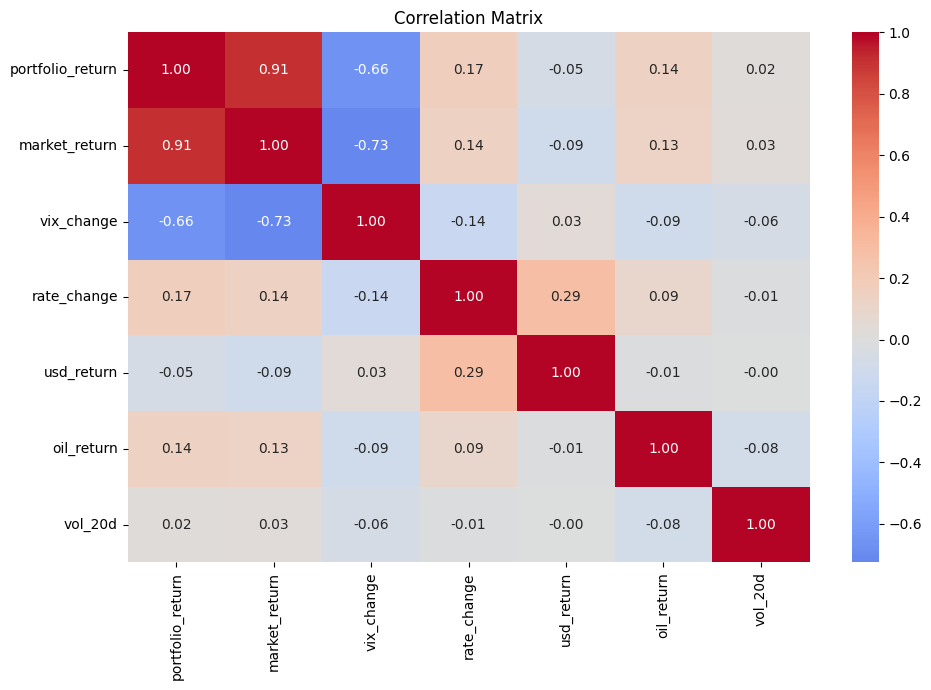

In [45]:
correlation_features = [
    "portfolio_return",
    "market_return",
    "vix_change",
    "rate_change",
    "usd_return",
    "oil_return",
    "vol_20d"
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[correlation_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

As can be seen, portfolio return is strongly correlated to the market return while VIX shows negative relationship towards those two metrics.

In [46]:
features = [
    "market_return",
    "vix_change",
    "rate_change",
    "usd_return",
    "oil_return",
    "ret_lag1",
    "ret_lag2",
    "ret_lag5",
    "vol_5d",
    "vol_20d",
    "vol_60d",
    "drawdown_60d",
    "portfolio_volume_change"
]

X = df[features]
y = df["target_return"]

print("Number of features:", len(features))
print("\nFeatures:")
for i, feature in enumerate(features, start=1):
    print(f"{i}. {feature}")

Number of features: 13

Features:
1. market_return
2. vix_change
3. rate_change
4. usd_return
5. oil_return
6. ret_lag1
7. ret_lag2
8. ret_lag5
9. vol_5d
10. vol_20d
11. vol_60d
12. drawdown_60d
13. portfolio_volume_change


In [47]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

X_train = train[features]
y_train = train["target_return"]

X_val = val[features]
y_val = val["target_return"]

X_test = test[features]
y_test = test["target_return"]

print("Dataset sizes:")
print(f"Training:   {len(train):,}")
print(f"Validation: {len(val):,}")
print(f"Test:       {len(test):,}")

print("\nDate ranges:")

print(
    "Train:",
    train.index.min().date(),
    "→",
    train.index.max().date()
)

print(
    "Validation:",
    val.index.min().date(),
    "→",
    val.index.max().date()
)

print(
    "Test:",
    test.index.min().date(),
    "→",
    test.index.max().date()
)

Dataset sizes:
Training:   2,019
Validation: 433
Test:       433

Date ranges:
Train: 2015-03-31 → 2023-04-04
Validation: 2023-04-05 → 2024-12-23
Test: 2024-12-24 → 2026-09-10


## Why do we not use random train_test_split?

Financial data is time-dependent. Using a random split could allow information from the future to enter the training set while older observations are placed in the test set. That would create bias.

Therefore, this project uses:

**Past → Training → Validation → Future Test**

This better represents how the model would operate in real risk management.

## Building a baseline

Here, the baseline is naive on purpose: it just takes the 5% quantile of historical portfolio returns from the training period and uses that same fixed number as "tomorrow's worst-case return," every single day, regardless of current market conditions.


In [48]:
# Historical 5% quantile calculated only from training data
baseline_q = y_train.quantile(ALPHA)

baseline_val = np.full(
    len(y_val),
    baseline_q
)

baseline_test = np.full(
    len(y_test),
    baseline_q
)

print(
    f"Historical baseline 5% quantile: "
    f"{baseline_q:.4%}"
)

Historical baseline 5% quantile: -2.4584%


## What is "Quantile Regression"?

Ordinary regression predicts the average outcome. Quantile regression instead predicts a specific percentile of the outcome. In our case we don't actually care what the portfolio does on a typical day, we care specifically about how bad the bad days can get.

In [49]:
linear_qr = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        QuantileRegressor(
            quantile=ALPHA,
            alpha=0.01,
            solver="highs"
        )
    )
])

linear_qr.fit(
    X_train,
    y_train
)

pred_val_linear = linear_qr.predict(X_val)
pred_test_linear = linear_qr.predict(X_test)

print("Linear Quantile Regression trained successfully.")

Linear Quantile Regression trained successfully.


## Tuning the XGBoost model



In [50]:
import itertools

xgb_param_grid = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05],
    "n_estimators": [300, 500],
    "min": [4, 8],
}

keys = list(xgb_param_grid.keys())
combinations = list(itertools.product(*xgb_param_grid.values()))

print(f"Testing {len(combinations)} hyperparameter combinations on the validation set...")

best_val_score = np.inf
best_params = None

for combo in combinations:
    params = dict(zip(keys, combo))

    candidate = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=ALPHA,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=5.0,
        reg_alpha=0.1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
    )

    candidate.fit(X_train, y_train, verbose=False)

    val_pred = candidate.predict(X_val)
    val_score = mean_pinball_loss(y_val, val_pred, alpha=ALPHA)

    if val_score < best_val_score:
        best_val_score = val_score
        best_params = params

print("Best hyperparameters found (lowest validation Pinball Loss):")
print(best_params)
print(f"Validation Pinball Loss with these settings: {best_val_score:.6f}")


Testing 36 hyperparameter combinations on the validation set...
Best hyperparameters found (lowest validation Pinball Loss):
{'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 500, 'min': 4}
Validation Pinball Loss with these settings: 0.001220


In [51]:
xgb_qr = XGBRegressor(
    objective="reg:quantileerror",
    quantile_alpha=ALPHA,

    subsample=0.85,
    colsample_bytree=0.85,

    reg_lambda=5.0,
    reg_alpha=0.1,

    random_state=RANDOM_STATE,
    n_jobs=-1,

    **best_params
)

xgb_qr.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

pred_val_xgb = xgb_qr.predict(X_val)
pred_test_xgb = xgb_qr.predict(X_test)

print("XGBoost Quantile Regression trained successfully with tuned hyperparameters.")


XGBoost Quantile Regression trained successfully with tuned hyperparameters.


## How we're scoring the models

- **Pinball Loss** - the metric quantile regression is actually trained to minimize. It penalizes the model more for underestimating risk (predicting a milder worst-case than what really happened) than for overestimating it, since underestimating risk is the more dangerous mistake for a risk model to make. Lower is better.
- **MAE (Mean Absolute Error)** - the plain average size of the prediction error, in the same units as returns. Easier to read intuitively, but treats over- and under-estimating risk as equally bad, which isn't quite true for this use case - that's why Pinball Loss, not MAE, is used to pick the winning model below.


In [52]:
validation_results = pd.DataFrame([
    {
        "Model": "Historical Quantile",
        "Pinball Loss": mean_pinball_loss(
            y_val,
            baseline_val,
            alpha=ALPHA
        ),
        "MAE": mean_absolute_error(
            y_val,
            baseline_val
        )
    },

    {
        "Model": "Linear Quantile Regression",
        "Pinball Loss": mean_pinball_loss(
            y_val,
            pred_val_linear,
            alpha=ALPHA
        ),
        "MAE": mean_absolute_error(
            y_val,
            pred_val_linear
        )
    },

    {
        "Model": "XGBoost Quantile Regression",
        "Pinball Loss": mean_pinball_loss(
            y_val,
            pred_val_xgb,
            alpha=ALPHA
        ),
        "MAE": mean_absolute_error(
            y_val,
            pred_val_xgb
        )
    }
])

validation_results = validation_results.sort_values(
    "Pinball Loss"
)

display(validation_results)

,Model,Pinball Loss,MAE
2,XGBoost Quantile Regression,0.001220,0.019720
1,Linear Quantile Regression,0.001250,0.021719
0,Historical Quantile,0.001398,0.026437


In [53]:
best_model_name = validation_results.iloc[0]["Model"]

print("Best model based on validation Pinball Loss:")
print(best_model_name)

Best model based on validation Pinball Loss:
XGBoost Quantile Regression


In [54]:
from sklearn.metrics import r2_score
test_predictions = {
    "Historical Quantile": baseline_test,
    "Linear Quantile Regression": pred_test_linear,
    "XGBoost Quantile Regression": pred_test_xgb
}

test_results = []

for model_name, predictions in test_predictions.items():

    pinball = mean_pinball_loss(
        y_test,
        predictions,
        alpha=ALPHA
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    breaches = y_test < predictions

    breach_rate = breaches.mean()

    test_results.append({
        "Model": model_name,
        "Pinball Loss": pinball,
        "MAE": mae,
        "VaR Breach Rate": breach_rate,
        "Number of Breaches": breaches.sum()
    })

test_results = pd.DataFrame(test_results)

display(
    test_results.sort_values("Pinball Loss")
)

,Model,Pinball Loss,MAE,VaR Breach Rate,Number of Breaches
2,XGBoost Quantile Regression,0.001403,0.020650,0.048499,21
1,Linear Quantile Regression,0.001420,0.022066,0.036952,16
0,Historical Quantile,0.001581,0.026149,0.023095,10


XGBoost Quantile Regression demonstrated the best predictive performance, achieving the lowest pinball loss (0.001401) and MAE (0.020671). Its VaR breach rate of 4.85% was also closest to the expected 5% level for a 95% VaR, indicating comparatively better calibration.

In [55]:
from scipy import stats

def kupiec_pof_test(breaches, confidence_level=0.95):
    n = len(breaches)
    x = int(breaches.sum())
    p = 1 - confidence_level                  # expected breach prob (0.05)
    p_hat = x / n                             # observed breach rate

    # Likelihood ratio statistic
    if x == 0:
        lr = -2 * n * np.log(1 - p)
    else:
        lr = -2 * (np.log((1 - p) ** (n - x) * p ** x)
                   - np.log((1 - p_hat) ** (n - x) * p_hat ** x))

    p_value = 1 - stats.chi2.cdf(lr, df=1)
    return lr, p_value, p_hat


print(f"{'Model':<28} {'Breaches':>9} {'Rate':>8} {'LR stat':>9} {'p-value':>9}  Calibrated?")
print("-" * 80)
for name, pred in [("XGBoost",        pred_test_xgb),
                   ("Linear",         pred_test_linear),
                   ("Historical",     baseline_test)]:
    breaches = y_test.values < np.asarray(pred)
    lr, p, rate = kupiec_pof_test(breaches, CONFIDENCE)
    ok = "YES" if p > 0.05 else "NO"
    print(f"{name:<28} {int(breaches.sum()):>9} {rate:>7.2%} {lr:>9.3f} {p:>9.4f}  {ok}")

Model                         Breaches     Rate   LR stat   p-value  Calibrated?
--------------------------------------------------------------------------------
XGBoost                             21   4.85%     0.021    0.8855  YES
Linear                              16   3.70%     1.700    0.1923  YES
Historical                          10   2.31%     8.178    0.0042  NO


the Kupiec POF test for calibration: the historical baseline is rejected (p < 0.01), the linear model is borderline, and XGBoost fails to reject the null hypothesis of correct calibration (p ≈ 0.88). In other words, XGBoost's breach rate of 4.85% is statistically indistinguishable from the 5% target.

So the honest story is: the ML models clearly beat the naive baseline, and among the ML models, XGBoost is the one that's actually well-calibrated

In [56]:
if best_model_name == "Historical Quantile":
    best_pred = baseline_test

elif best_model_name == "Linear Quantile Regression":
    best_pred = pred_test_linear

else:
    best_pred = pred_test_xgb

print("Selected model:")
print(best_model_name)

Selected model:
XGBoost Quantile Regression


The chart below plots the actual daily return (blue) against the model's predicted worst-case 5% line (orange) for the test period. The highlighted points are **breaches** — days where the real outcome was worse than what the model predicted. For a well-calibrated model, these should be scattered thinly across the chart, at roughly the expected 5% rate, not clustered together.


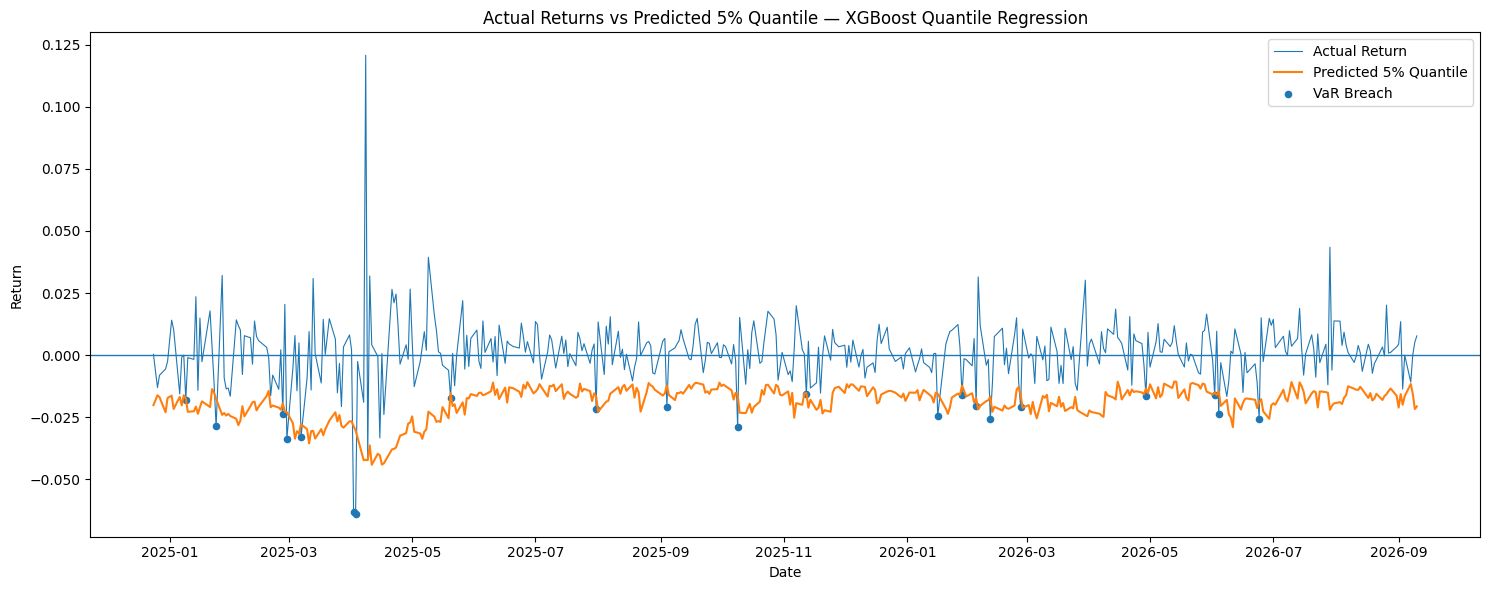

In [57]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.index,
    y_test,
    linewidth=0.8,
    label="Actual Return"
)

plt.plot(
    y_test.index,
    best_pred,
    linewidth=1.5,
    label="Predicted 5% Quantile"
)

breaches = y_test < best_pred

plt.scatter(
    y_test.index[breaches],
    y_test[breaches],
    s=20,
    label="VaR Breach"
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    f"Actual Returns vs Predicted 5% Quantile — {best_model_name}"
)

plt.xlabel("Date")
plt.ylabel("Return")

plt.legend()

plt.tight_layout()
plt.show()

## Turning percentages into dollars

Everything so far has been in percentage-return terms. This step converts it into the number people actually care about: for a $1,000,000 portfolio, what does the predicted worst case mean in dollars, and how did that compare to what actually happened?


In [58]:
risk = pd.DataFrame(index=y_test.index)

risk["actual_return"] = y_test

risk["predicted_q05"] = best_pred

risk["VaR_return"] = np.maximum(
    0,
    -risk["predicted_q05"]
)

risk["VaR_$"] = (
    PORTFOLIO_VALUE *
    risk["VaR_return"]
)

risk["actual_PnL_$"] = (
    PORTFOLIO_VALUE *
    risk["actual_return"]
)

risk["breach"] = (
    risk["actual_return"] <
    risk["predicted_q05"]
)

display(risk.head())

,actual_return,predicted_q05,VaR_return,VaR_$,actual_PnL_$,breach
Date,,,,,,
2024-12-24,0.000327,-0.020124,0.020124,20124.392578,326.757427,False
2024-12-26,-0.013039,-0.016160,0.016160,16160.299805,-13038.917623,False
2024-12-27,-0.008090,-0.016930,0.016930,16929.816406,-8089.926738,False
2024-12-30,-0.005567,-0.022995,0.022995,22995.046875,-5567.405874,False
2024-12-31,-0.002485,-0.017220,0.017220,17219.765625,-2484.924038,False


In [59]:
summary = pd.Series({
    "Portfolio value": PORTFOLIO_VALUE,

    "Average predicted VaR ($)":
        risk["VaR_$"].mean(),

    "Median predicted VaR ($)":
        risk["VaR_$"].median(),

    "Maximum predicted VaR ($)":
        risk["VaR_$"].max(),

    "Worst actual P&L ($)":
        risk["actual_PnL_$"].min(),

    "VaR breach rate":
        risk["breach"].mean()
})

display(summary.to_frame("Value"))

,Value
Portfolio value,1000000.000000
Average predicted VaR ($),18870.056641
Median predicted VaR ($),17152.822266
Maximum predicted VaR ($),44128.316406
Worst actual P&L ($),-63847.637168
VaR breach rate,0.048499


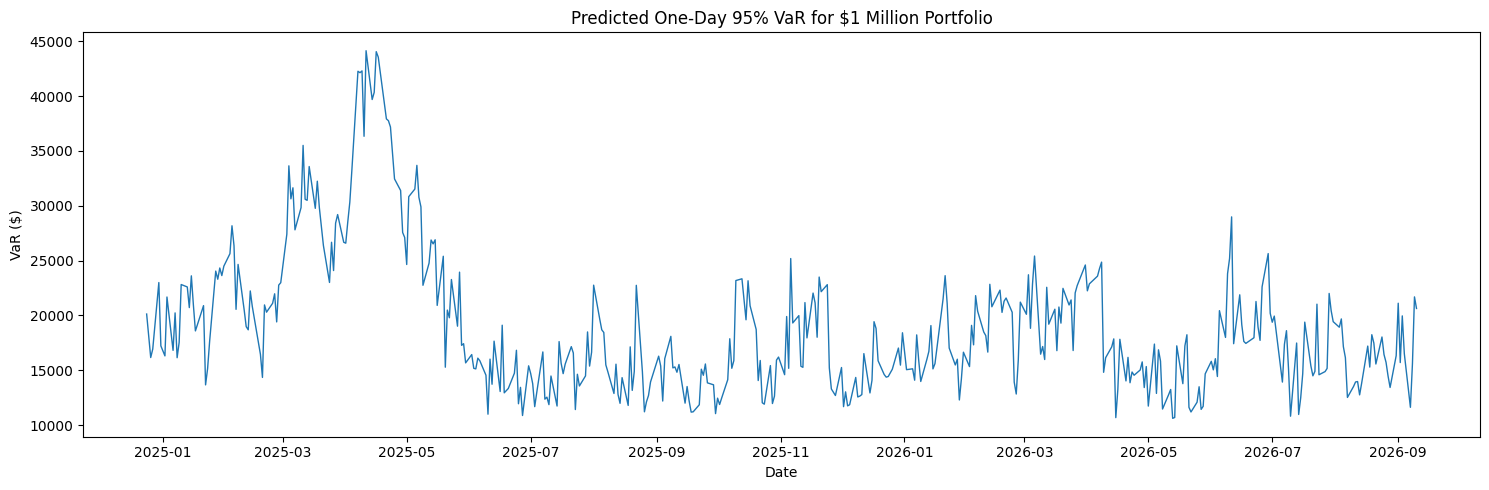

In [60]:
plt.figure(figsize=(15, 5))

plt.plot(
    risk.index,
    risk["VaR_$"],
    linewidth=1
)

plt.title(
    "Predicted One-Day 95% VaR for $1 Million Portfolio"
)

plt.xlabel("Date")
plt.ylabel("VaR ($)")

plt.tight_layout()
plt.show()

## Which inputs mattered most?


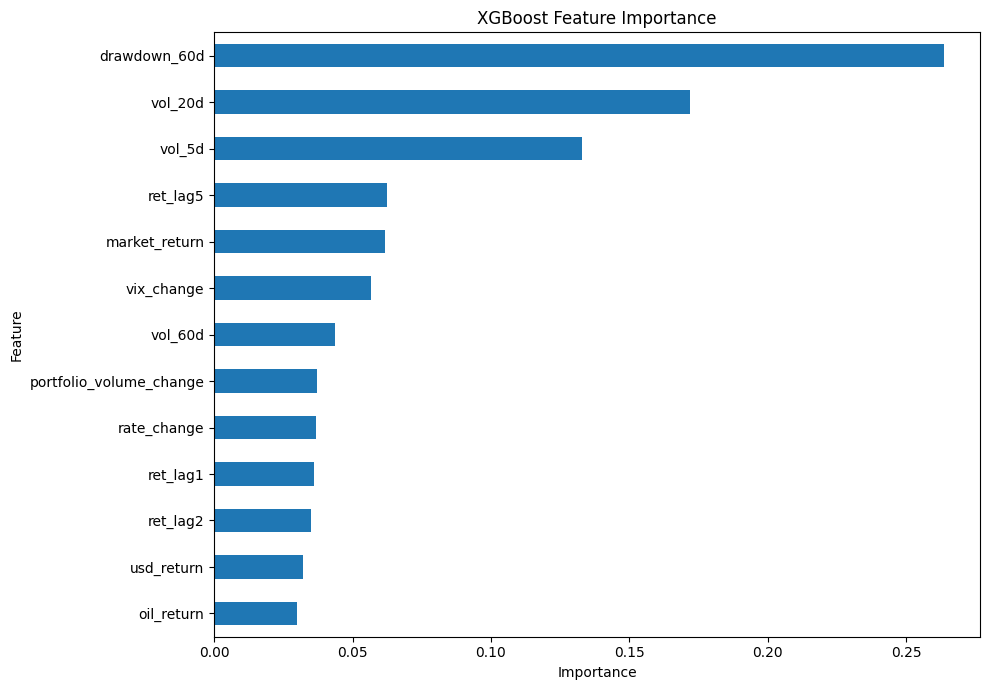

In [61]:
importance = pd.Series(
    xgb_qr.feature_importances_,
    index=features
).sort_values(
    ascending=True
)

plt.figure(figsize=(10, 7))

importance.plot(
    kind="barh"
)

plt.title(
    "XGBoost Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The high importance of drawdown indicates that the model places substantial weight on the portfolio's recent cumulative losses when estimating downside risk. This suggests that the current state of portfolio deterioration is an important predictor of future tail losses.

In [62]:
feature_importance = pd.DataFrame({
    "Feature": importance.index,
    "Importance": importance.values
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
12,drawdown_60d,0.263565
11,vol_20d,0.171933
10,vol_5d,0.133013
9,ret_lag5,0.062380
8,market_return,0.061839
7,vix_change,0.056600
6,vol_60d,0.043669
5,portfolio_volume_change,0.036987
4,rate_change,0.036982
3,ret_lag1,0.036163


## Stress testing

Stress testing here means specifically pulling out the 10 days in the test period with the biggest moves in the VIX (the market's "fear gauge") - i.e., the most turbulent days - and checking how the model's predicted worst-case loss compared to what actually happened on those specific days.


In [63]:
stress = test[
    [
        "portfolio_return",
        "vix_change",
        "market_return"
    ]
].copy()

stress["predicted_q05"] = best_pred

stress["actual_loss_$"] = (
    -PORTFOLIO_VALUE *
    stress["portfolio_return"]
)

stress["predicted_VaR_$"] = (
    -PORTFOLIO_VALUE *
    stress["predicted_q05"]
).clip(lower=0)

# Select days with the largest absolute VIX changes
stress = stress.loc[
    stress["vix_change"].abs()
    .nlargest(10)
    .index
]

stress = stress.sort_index()

display(stress)

,portfolio_return,vix_change,market_return,predicted_q05,actual_loss_$,predicted_VaR_$
Date,,,,,,
2025-04-03,-0.062975,0.395630,-0.048396,-0.030329,62974.818230,30328.751953
2025-04-04,-0.063848,0.509327,-0.059750,-0.033224,63847.637168,33223.683594
2025-04-09,0.120672,-0.357539,0.095154,-0.042288,-120672.450184,42288.289062
2025-04-10,-0.041226,0.211184,-0.034608,-0.036327,41225.664931,36327.363281
2025-08-01,-0.021483,0.218900,-0.015992,-0.022756,21483.203219,22756.076172
2025-10-10,-0.029052,0.318320,-0.027112,-0.023177,29052.458441,23177.476562
2025-10-16,-0.005391,0.226260,-0.006294,-0.023157,5391.210888,23157.298828
2026-01-20,-0.024318,0.266709,-0.020627,-0.021516,24317.900682,21516.101562
2026-03-06,-0.011419,0.241684,-0.013277,-0.025411,11418.698295,25411.353516


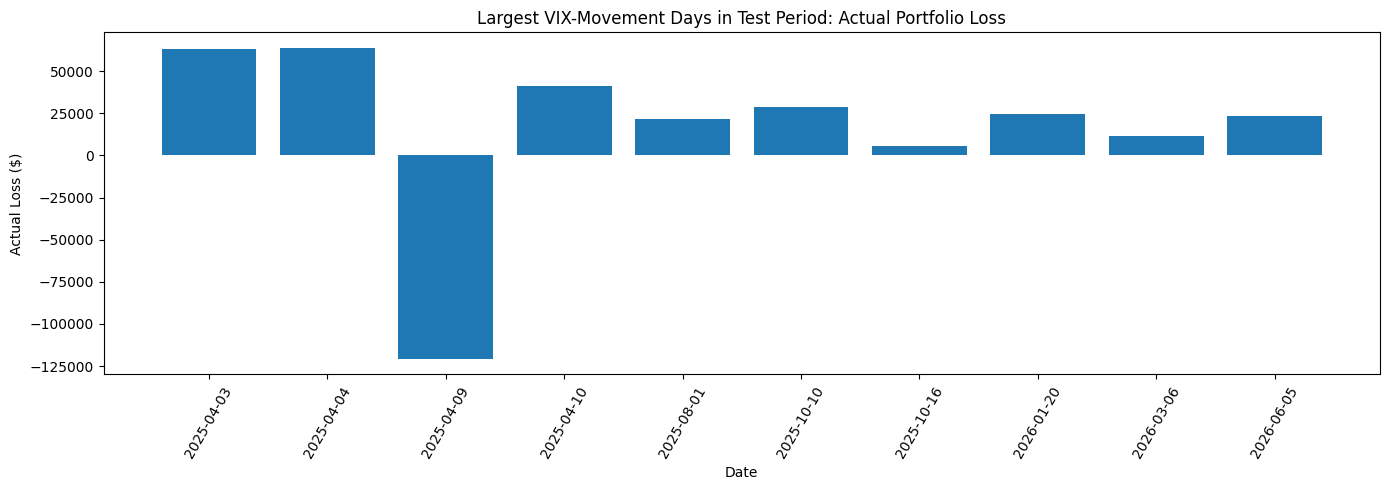

In [64]:
plt.figure(figsize=(14, 5))

plt.bar(
    stress.index.astype(str),
    stress["actual_loss_$"]
)

plt.xticks(
    rotation=60
)

plt.title(
    "Largest VIX-Movement Days in Test Period: Actual Portfolio Loss"
)

plt.xlabel("Date")
plt.ylabel("Actual Loss ($)")

plt.tight_layout()
plt.show()

## Saving the model for reuse




In [65]:
import os
os.makedirs('ml-api', exist_ok=True)
print('Готово. Папка проекта: ml-api')

artifact = {
    "model": xgb_qr,
    "features": features,
    "alpha": ALPHA,
    "confidence": CONFIDENCE,
    "portfolio_weights": weights.to_dict(),
    "default_portfolio_value": PORTFOLIO_VALUE
}

joblib.dump(
    artifact,
    "ml-api/ml_var_xgboost.pkl"
)

print("Model saved as: ml_var_xgboost.pkl")

Готово. Папка проекта: ml-api
Model saved as: ml_var_xgboost.pkl


In [66]:
loaded_artifact = joblib.load(
    "ml-api/ml_var_xgboost.pkl"
)

loaded_model = loaded_artifact["model"]
loaded_features = loaded_artifact["features"]

test_prediction = loaded_model.predict(
    X_test.iloc[[0]][loaded_features]
)[0]

print(
    f"Test prediction from saved model: "
    f"{test_prediction:.4%}"
)

Test prediction from saved model: -2.0124%


In [67]:
import sklearn
import pandas as pd
import numpy as np
import joblib
import scipy

requirements = [
    "fastapi",
    "uvicorn[standard]",
    "requests",

    "numpy",
    "pandas",
    "scikit-learn",
    "joblib",
    "scipy",

    "xgboost",

    "matplotlib",
    "yfinance",
    "seaborn",
    "statsmodels"
]

with open("ml-api/requirements.txt", "w") as file:
    file.write("\n".join(requirements))

print("\n".join(requirements))

fastapi
uvicorn[standard]
requests
numpy
pandas
scikit-learn
joblib
scipy
xgboost
matplotlib
yfinance
seaborn
statsmodels


In [68]:
api_code = r'''
from fastapi import FastAPI
from pydantic import BaseModel, Field
import joblib
import pandas as pd

artifact = joblib.load("ml_var_xgboost.joblib")

model = artifact["model"]
features = artifact["features"]

app = FastAPI(
    title="ML-VaR Risk Forecast API",
    version="1.0"
)


class RiskRequest(BaseModel):

    market_return: float
    vix_change: float
    rate_change: float
    usd_return: float
    oil_return: float

    ret_lag1: float
    ret_lag2: float
    ret_lag5: float

    vol_5d: float
    vol_20d: float
    vol_60d: float

    drawdown_60d: float
    portfolio_volume_change: float

    portfolio_value: float = Field(
        default=1000000,
        gt=0
    )


@app.get("/")
def root():

    return {
        "message": "ML-VaR API is running"
    }


@app.post("/predict")
def predict(request: RiskRequest):

    data = request.model_dump()

    portfolio_value = data.pop(
        "portfolio_value"
    )

    row = pd.DataFrame(
        [data]
    )[features]

    predicted_q05 = float(
        model.predict(row)[0]
    )

    var_return = max(
        0.0,
        -predicted_q05
    )

    var_dollars = (
        portfolio_value *
        var_return
    )

    return {
        "confidence_level": 0.95,
        "predicted_5_percent_return":
            predicted_q05,
        "one_day_var_return":
            var_return,
        "one_day_var_dollars":
            var_dollars
    }
'''

with open(
    "app.py",
    "w",
    encoding="utf-8"
) as f:

    f.write(api_code)

print("FastAPI application saved as app.py")

FastAPI application saved as app.py


In [69]:
print(api_code)


from fastapi import FastAPI
from pydantic import BaseModel, Field
import joblib
import pandas as pd

artifact = joblib.load("ml_var_xgboost.joblib")

model = artifact["model"]
features = artifact["features"]

app = FastAPI(
    title="ML-VaR Risk Forecast API",
    version="1.0"
)


class RiskRequest(BaseModel):

    market_return: float
    vix_change: float
    rate_change: float
    usd_return: float
    oil_return: float

    ret_lag1: float
    ret_lag2: float
    ret_lag5: float

    vol_5d: float
    vol_20d: float
    vol_60d: float

    drawdown_60d: float
    portfolio_volume_change: float

    portfolio_value: float = Field(
        default=1000000,
        gt=0
    )


@app.get("/")
def root():

    return {
        "message": "ML-VaR API is running"
    }


@app.post("/predict")
def predict(request: RiskRequest):

    data = request.model_dump()

    portfolio_value = data.pop(
        "portfolio_value"
    )

    row = pd.DataFrame(
        [data]
    )[features]

    pr

In [70]:
%%writefile ml-api/main.py

from fastapi import FastAPI
from fastapi.responses import FileResponse
from pydantic import BaseModel, Field
import joblib
import pandas as pd

app = FastAPI(
    title="Portfolio VaR Prediction API",
    version="1.0"
)

artifact = joblib.load("ml_var_xgboost.pkl")

model = artifact["model"]
features = artifact["features"]
alpha = artifact["alpha"]
confidence = artifact["confidence"]
default_portfolio_value = artifact["default_portfolio_value"]

class VaRInput(BaseModel):

    market_return: float
    vix_change: float
    rate_change: float
    usd_return: float
    oil_return: float

    ret_lag1: float
    ret_lag2: float
    ret_lag5: float

    vol_5d: float
    vol_20d: float
    vol_60d: float

    drawdown_60d: float
    portfolio_volume_change: float

    portfolio_value: float = Field(
        default=default_portfolio_value,
        gt=0,
        description="Portfolio value in USD"
    )


@app.get("/")
def home():

    return {
        "message": "Portfolio VaR Prediction API",
        "documentation": "/docs",
        "health_check": "/health"
    }


@app.get("/health")
def health():

    return {
        "status": "healthy"
    }


@app.get("/info")
def info():

    return {
        "model": "XGBoost Quantile Regression",
        "quantile": alpha,
        "confidence": confidence,
        "features": features,
        "default_portfolio_value": default_portfolio_value,
        "version": "1.0"
    }


@app.post("/predict")
def predict(var_input: VaRInput):

    input_data = {
        feature: getattr(var_input, feature)
        for feature in features
    }

    X = pd.DataFrame(
        [input_data],
        columns=features
    )

    predicted_return = float(
        model.predict(X)[0]
    )

    portfolio_value = var_input.portfolio_value

    predicted_var = max(
        -predicted_return * portfolio_value,
        0
    )

    return {
        "confidence_level": confidence,
        "alpha": alpha,
        "predicted_5pct_return": predicted_return,
        "predicted_VaR": predicted_var,
        "portfolio_value": portfolio_value
    }

@app.get("/app")
def app_page():
    return FileResponse("index.html")

Writing ml-api/main.py


In [71]:
%%writefile ml-api/index.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Portfolio VaR Prediction</title>

    <style>
        body {
            font-family: Arial, sans-serif;
            background-color: #f4f6f8;
            margin: 0;
            padding: 40px;
        }

        .container {
            max-width: 900px;
            margin: auto;
            background: white;
            padding: 30px;
            border-radius: 10px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }

        h1 {
            text-align: center;
            margin-bottom: 10px;
        }

        .description {
            text-align: center;
            color: #666;
            margin-bottom: 30px;
        }

        .section {
            margin-top: 25px;
            margin-bottom: 10px;
            font-size: 20px;
            font-weight: bold;
        }

        .form-grid {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 15px;
        }

        .form-group {
            display: flex;
            flex-direction: column;
        }

        label {
            margin-bottom: 5px;
            font-weight: bold;
        }

        input {
            padding: 10px;
            border: 1px solid #ccc;
            border-radius: 5px;
            font-size: 14px;
        }

        input:focus {
            outline: none;
            border-color: #555;
        }

        button {
            width: 100%;
            margin-top: 25px;
            padding: 13px;
            font-size: 16px;
            font-weight: bold;
            border: none;
            border-radius: 5px;
            cursor: pointer;
        }

        .result {
            margin-top: 25px;
            padding: 20px;
            background-color: #f1f3f5;
            border-radius: 8px;
            display: none;
        }

        .result h2 {
            margin-top: 0;
        }

        .result-value {
            font-size: 24px;
            font-weight: bold;
            margin: 10px 0;
        }

        .error {
            margin-top: 20px;
            padding: 15px;
            background-color: #ffe5e5;
            color: #b00020;
            border-radius: 5px;
            display: none;
        }

        @media (max-width: 700px) {
            .form-grid {
                grid-template-columns: 1fr;
            }

            body {
                padding: 15px;
            }
        }
    </style>
</head>

<body>

<div class="container">

    <h1>Portfolio VaR Prediction</h1>

    <p class="description">
        XGBoost Quantile Regression Model
        <br>
        5% VaR at 95% confidence level
    </p>

    <div class="section">
        Market Features
    </div>

    <div class="form-grid">

        <div class="form-group">
            <label for="market_return">Market Return</label>
            <input type="number" id="market_return" step="any" value="0">
        </div>

        <div class="form-group">
            <label for="vix_change">VIX Change</label>
            <input type="number" id="vix_change" step="any" value="0">
        </div>

        <div class="form-group">
            <label for="rate_change">Rate Change</label>
            <input type="number" id="rate_change" step="any" value="0">
        </div>

        <div class="form-group">
            <label for="usd_return">USD Return</label>
            <input type="number" id="usd_return" step="any" value="0">
        </div>

        <div class="form-group">
            <label for="oil_return">Oil Return</label>
            <input type="number" id="oil_return" step="any" value="0">
        </div>

        <div class="form-group">
            <label for="ret_lag1">Return Lag 1</label>
            <input type="number" id="ret_lag1" step="any" value="0">
        </div>

        <div class="form-group">
            <label for="ret_lag2">Return Lag 2</label>
            <input type="number" id="ret_lag2" step="any" value="0">
        </div>

        <div class="form-group">
            <label for="ret_lag5">Return Lag 5</label>
            <input type="number" id="ret_lag5" step="any" value="0">
        </div>

        <div class="form-group">
            <label for="vol_5d">Volatility 5D</label>
            <input type="number" id="vol_5d" step="any" value="0">
        </div>

        <div class="form-group">
            <label for="vol_20d">Volatility 20D</label>
            <input type="number" id="vol_20d" step="any" value="0">
        </div>

        <div class="form-group">
            <label for="vol_60d">Volatility 60D</label>
            <input type="number" id="vol_60d" step="any" value="0">
        </div>

        <div class="form-group">
            <label for="drawdown_60d">Drawdown 60D</label>
            <input type="number" id="drawdown_60d" step="any" value="0">
        </div>

        <div class="form-group">
            <label for="portfolio_volume_change">
                Portfolio Volume Change
            </label>
            <input type="number"
                   id="portfolio_volume_change"
                   step="any"
                   value="0">
        </div>

    </div>

    <div class="section">
        Portfolio Information
    </div>

    <div class="form-grid">

        <div class="form-group">
            <label for="portfolio_value">
                Portfolio Value (USD)
            </label>

            <input type="number"
                   id="portfolio_value"
                   step="any"
                   value="100000">
        </div>

    </div>

    <button onclick="predictVaR()">
        Predict VaR
    </button>

    <div id="error" class="error"></div>

    <div id="result" class="result">

        <h2>Prediction Result</h2>

        <p>
            Confidence Level:
            <strong id="confidence"></strong>
        </p>

        <p>
            Predicted 5% Return:
        </p>

        <div class="result-value" id="predicted_return"></div>

        <p>
            Portfolio Value:
        </p>

        <div class="result-value" id="portfolio_result"></div>

        <p>
            Predicted VaR:
        </p>

        <div class="result-value" id="predicted_var"></div>

    </div>

</div>


<script>

async function predictVaR() {

    const errorBox = document.getElementById("error");
    const resultBox = document.getElementById("result");

    errorBox.style.display = "none";
    resultBox.style.display = "none";

    const data = {

        market_return:
            parseFloat(document.getElementById("market_return").value),

        vix_change:
            parseFloat(document.getElementById("vix_change").value),

        rate_change:
            parseFloat(document.getElementById("rate_change").value),

        usd_return:
            parseFloat(document.getElementById("usd_return").value),

        oil_return:
            parseFloat(document.getElementById("oil_return").value),

        ret_lag1:
            parseFloat(document.getElementById("ret_lag1").value),

        ret_lag2:
            parseFloat(document.getElementById("ret_lag2").value),

        ret_lag5:
            parseFloat(document.getElementById("ret_lag5").value),

        vol_5d:
            parseFloat(document.getElementById("vol_5d").value),

        vol_20d:
            parseFloat(document.getElementById("vol_20d").value),

        vol_60d:
            parseFloat(document.getElementById("vol_60d").value),

        drawdown_60d:
            parseFloat(document.getElementById("drawdown_60d").value),

        portfolio_volume_change:
            parseFloat(
                document.getElementById("portfolio_volume_change").value
            ),

        portfolio_value:
            parseFloat(
                document.getElementById("portfolio_value").value
            )
    };


    try {

        const response = await fetch("/predict", {

            method: "POST",

            headers: {
                "Content-Type": "application/json"
            },

            body: JSON.stringify(data)

        });


        const result = await response.json();


        if (!response.ok) {

            throw new Error(
                result.detail || "Prediction failed"
            );

        }


        document.getElementById("confidence").textContent =
            (result.confidence_level * 100).toFixed(0) + "%";


        document.getElementById("predicted_return").textContent =
            (result.predicted_5pct_return * 100).toFixed(4) + "%";


        document.getElementById("portfolio_result").textContent =
            "$" + result.portfolio_value.toLocaleString(
                undefined,
                {
                    minimumFractionDigits: 2,
                    maximumFractionDigits: 2
                }
            );


        document.getElementById("predicted_var").textContent =
            "$" + result.predicted_VaR.toLocaleString(
                undefined,
                {
                    minimumFractionDigits: 2,
                    maximumFractionDigits: 2
                }
            );


        resultBox.style.display = "block";

    }


    catch (error) {

        errorBox.textContent =
            "Error: " + error.message;

        errorBox.style.display = "block";

    }

}

</script>

</body>
</html>

Writing ml-api/index.html


In [72]:
print("Contents of ml-api:")

for file_name in sorted(os.listdir("ml-api")):
    file_path = os.path.join("ml-api", file_name)

    if os.path.isfile(file_path):
        print(
            file_name,
            "->",
            os.path.getsize(file_path),
            "bytes"
        )

Contents of ml-api:
index.html -> 9418 bytes
main.py -> 2170 bytes
ml_var_xgboost.pkl -> 567817 bytes
requirements.txt -> 121 bytes


In [73]:
import subprocess
import time

server_process = subprocess.Popen(
    [
        "uvicorn",
        "main:app",
        "--host",
        "0.0.0.0",
        "--port",
        "8000"
    ],
    cwd="ml-api"
)

time.sleep(8)

print("FastAPI server started.")
print("PID:", server_process.pid)

FastAPI server started.
PID: 2151


In [74]:
import threading
import time
import requests
import uvicorn

config = uvicorn.Config("app:app", host="127.0.0.1", port=8000, log_level="warning")
server = uvicorn.Server(config)

server_thread = threading.Thread(target=server.run, daemon=True)
server_thread.start()

time.sleep(2)  # give the server a moment to start up

sample_request = {
    "market_return": 0.001,
    "vix_change": 0.02,
    "rate_change": 0.01,
    "usd_return": -0.003,
    "oil_return": 0.005,
    "ret_lag1": 0.002,
    "ret_lag2": -0.001,
    "ret_lag5": 0.004,
    "vol_5d": 0.01,
    "vol_20d": 0.012,
    "vol_60d": 0.015,
    "drawdown_60d": -0.03,
    "portfolio_volume_change": 0.01,
    "portfolio_value": 1000000
}

response = requests.post("http://127.0.0.1:8000/predict", json=sample_request)

print("API response for a sample request:")
print(response.json())

server.should_exit = True
server_thread.join(timeout=5)

print("\nServer stopped. In production this would instead keep running, "
      "e.g. as a separate process started from a terminal or a Docker container.")


Exception in thread Thread-24 (run):
Traceback (most recent call last):
  File "/usr/lib/python3.13/threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/uvicorn/server.py", line 77, in run
    return asyncio_run(self.serve(sockets=sockets), loop_factory=self.config.get_loop_factory())
  File "/usr/lib/python3.13/asyncio/runners.py", line 196, in run
    return runner.run(main)
           ~~~~~~~~~~^^^^^^
  File "/usr/lib/python3.13/asyncio/runners.py", line 119, in run
    return self._loop.run_until_complete(task)
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "uvloop/loop.pyx", line 1518, in uvloop.loop.Loop.run_until_complete
  File "/usr/local/lib/python3.13/dist-packages/uvicorn/server.py", line 81, in serve
    await self._serve(sockets)
  File "/usr/loc

API response for a sample request:
{'confidence_level': 0.95, 'alpha': 0.05, 'predicted_5pct_return': -0.01563986949622631, 'predicted_VaR': 15639.86949622631, 'portfolio_value': 1000000.0}

Server stopped. In production this would instead keep running, e.g. as a separate process started from a terminal or a Docker container.


In [75]:
%%writefile ml-api/Dockerfile

FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY main.py .
COPY index.html .
COPY ml_var_xgboost.pkl .

EXPOSE 8000

CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000", "--workers", "2"]

Writing ml-api/Dockerfile


In [76]:
%%writefile ml-api/.dockerignore

__pycache__/
*.pyc
.git/
.env
*.log
*.ipynb

Writing ml-api/.dockerignore


# Conclusion

We built a tool that looks at today's market conditions and estimates how much a $1,000,000 stock portfolio could realistically lose tomorrow, on a bad (bottom-5%) day.

This project formulated Value-at-Risk forecasting as a supervised machine-learning problem.

Instead of assuming that portfolio returns follow a normal distribution, the models directly estimate the conditional 5th percentile of the next-day portfolio return.

Three approaches were compared:

1. Historical 5% quantile - baseline
2. Linear Quantile Regression - interpretable ML model
3. XGBoost Quantile Regression - nonlinear ML model

The models were evaluated using:

- Pinball Loss
- Mean Absolute Error
- VaR breach rate
- Stress-period analysis

The final model can transform market information into a monetary one-day 95% VaR estimate.

However, VaR does not describe the average size of losses beyond the VaR threshold. A natural extension of this project would therefore be Expected Shortfall (ES), as well as rolling or walk-forward model retraining.